In [ ]:
# Instalação das bibliotecas

!pip install osmnx
!pip install osmnx matplotlib


In [9]:
import osmnx as ox
import networkx as nx


In [14]:
# =====================================================================
# DOWNLOAD MULTI-BAIRRO (Nova Parnamirim + Coophab)
# =====================================================================
print("1. A iniciar o download da malha viária integrada...")

# Passamos uma lista de strings para o OSMnx baixar e costurar as malhas
bairros = [
    "Nova Parnamirim, Parnamirim, Rio Grande do Norte, Brazil",
    "Parque das Árvores, Parnamirim, Rio Grande do Norte, Brazil",
    "Parque do Jiqui, Parnamirim, Rio Grande do Norte, Brazil",
    "Parque das Nações, Parnamirim, Rio Grande do Norte, Brazil"
]

# Baixa a rede dos dois bairros já conectada
G = ox.graph_from_place(bairros, network_type="drive")
print(f"   -> Grafo original: {G.number_of_nodes()} nós e {G.number_of_edges()} arestas.")

# Limpeza e simplificação (mantém igual)
print("\n2. A converter e limpar o grafo para análises matemáticas...")
G_undirected = ox.convert.to_undirected(G)
G_simple = nx.Graph(G_undirected)
G_simple.remove_edges_from(nx.selfloop_edges(G_simple))
print(f"   -> Grafo limpo e pronto: {G_simple.number_of_nodes()} nós.")



1. A iniciar o download da malha viária integrada...
   -> Grafo original: 1594 nós e 3925 arestas.

2. A converter e limpar o grafo para análises matemáticas...
   -> Grafo limpo e pronto: 1594 nós.


In [15]:
# =====================================================================
# CÁLCULO DAS MÉTRICAS (NetworkX)
# =====================================================================
print("\n3. A calcular as Métricas de Rede...")

print("   -> A calcular Grau (Hubs)...")
degree_dict = dict(G_simple.degree())

print("   -> A calcular Betweenness Centrality (Gargalos) - com k=100...")
# Usamos k=100 para aproximar e não travar o computador
betweenness_dict = nx.betweenness_centrality(G_simple, k=100, normalized=True)

print("   -> A calcular K-Core Decomposition (Núcleo denso)...")
core_number_dict = nx.core_number(G_simple)





3. A calcular as Métricas de Rede...
   -> A calcular Grau (Hubs)...
   -> A calcular Betweenness Centrality (Gargalos) - com k=100...
   -> A calcular K-Core Decomposition (Núcleo denso)...


In [17]:
# =====================================================================
# RESULTADOS PARA A ANÁLISE / RELATÓRIO
# =====================================================================
print("\n" + "="*45)
print("             INSIGHTS DA REDE")
print("="*45)

# Top 10 Hubs
top_10_hubs = sorted(degree_dict.items(), key=lambda item: item[1], reverse=True)[:10]
print("\n📌 TOP 10 HUBS (Nós com mais conexões/cruzamentos complexos):")
for no, grau in top_10_hubs:
    print(f"ID: {no} | Grau: {grau}")

# Top 10 Gargalos
top_10_betweenness = sorted(betweenness_dict.items(), key=lambda item: item[1], reverse=True)[:10]
print("\n📌 TOP 10 GARGALOS (Maior centralidade de intermediação):")
for no, bc in top_10_betweenness:
    print(f"ID: {no} | Score: {bc:.4f}")

# Núcleo Denso
max_core = max(core_number_dict.values())
max_core_nodes = [no for no, core in core_number_dict.items() if core == max_core]
print("\n📌 DECOMPOSIÇÃO K-CORE:")
print(f"O Core máximo encontrado (Coração da rede) foi: K = {max_core}")
print(f"Quantidade de nós a formar este núcleo principal: {len(max_core_nodes)}")
print("="*45)




             INSIGHTS DA REDE

📌 TOP 10 HUBS (Nós com mais conexões/cruzamentos complexos):
ID: 501807613 | Grau: 4
ID: 501807660 | Grau: 4
ID: 501810217 | Grau: 4
ID: 501810223 | Grau: 4
ID: 501810268 | Grau: 4
ID: 501810273 | Grau: 4
ID: 501810369 | Grau: 4
ID: 501810378 | Grau: 4
ID: 501810382 | Grau: 4
ID: 502343302 | Grau: 4

📌 TOP 10 GARGALOS (Maior centralidade de intermediação):
ID: 3454188414 | Score: 0.4831
ID: 7246531423 | Score: 0.4518
ID: 4868575480 | Score: 0.3540
ID: 3454164765 | Score: 0.3431
ID: 3454164751 | Score: 0.3306
ID: 3454188380 | Score: 0.3233
ID: 3454188336 | Score: 0.3217
ID: 3454188299 | Score: 0.3082
ID: 3454188382 | Score: 0.3080
ID: 3454208304 | Score: 0.3064

📌 DECOMPOSIÇÃO K-CORE:
O Core máximo encontrado (Coração da rede) foi: K = 2
Quantidade de nós a formar este núcleo principal: 1401


      MÉTRICAS ADICIONAIS OBRIGATÓRIAS
-> A calcular Closeness Centrality...

📌 TOP 10 CENTROS (Maior Closeness):
ID: 501807605 | Score: 0.0567
ID: 3454188382 | Score: 0.0563
ID: 3454208089 | Score: 0.0561
ID: 3454208064 | Score: 0.0561
ID: 8633119591 | Score: 0.0558
ID: 3454188414 | Score: 0.0558
ID: 3454188380 | Score: 0.0558
ID: 3454208061 | Score: 0.0557
ID: 3454208304 | Score: 0.0556
ID: 3454208081 | Score: 0.0555

-> A gerar Gráfico de Distribuição de Grau...


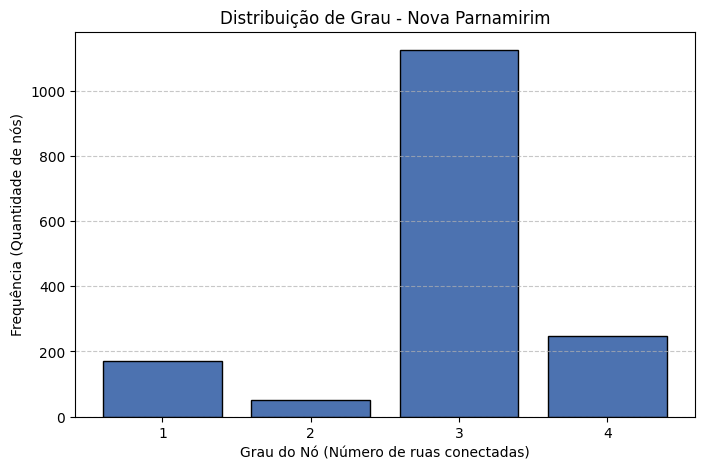

In [18]:
# =====================================================================
# MÉTRICAS FALTANTES (Distribuição de Grau e Closeness)
# =====================================================================
import matplotlib.pyplot as plt
from collections import Counter

print("="*45)
print("      MÉTRICAS ADICIONAIS OBRIGATÓRIAS")
print("="*45)

# 1. Closeness Centrality (Centros Estruturais)
print("-> A calcular Closeness Centrality...")
closeness_dict = nx.closeness_centrality(G_simple)

# Opcional: Salvar no grafo para exportar pro Gephi depois
nx.set_node_attributes(G_simple, closeness_dict, "closeness")

top_10_closeness = sorted(closeness_dict.items(), key=lambda item: item[1], reverse=True)[:10]
print("\n📌 TOP 10 CENTROS (Maior Closeness):")
for no, cc in top_10_closeness:
    print(f"ID: {no} | Score: {cc:.4f}")

print("="*45)

# 2. Distribuição de Grau (Gráfico)
print("\n-> A gerar Gráfico de Distribuição de Grau...")
graus = list(degree_dict.values())
distribuicao = Counter(graus)

plt.figure(figsize=(8, 5))
plt.bar(distribuicao.keys(), distribuicao.values(), color='#4C72B0', edgecolor='black')
plt.title("Distribuição de Grau - Nova Parnamirim")
plt.xlabel("Grau do Nó (Número de ruas conectadas)")
plt.ylabel("Frequência (Quantidade de nós)")
plt.xticks(list(distribuicao.keys()))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


-> A gerar Histogramas de Centralidade...


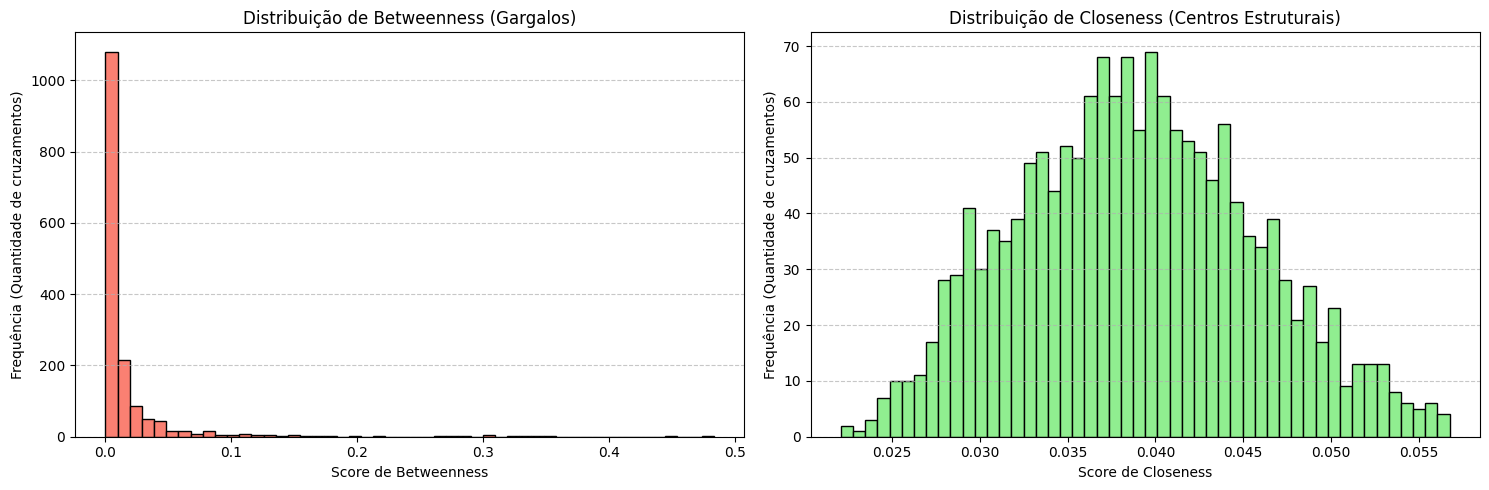

In [19]:
# =====================================================================
# HISTOGRAMAS DE CENTRALIDADE (Betweenness e Closeness)
# =====================================================================
import matplotlib.pyplot as plt

print("-> A gerar Histogramas de Centralidade...")

# Prepara a figura com dois gráficos lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- Gráfico 1: Betweenness Centrality ---
valores_betweenness = list(betweenness_dict.values())
# Usamos bins=50 para dividir os decimais em 50 "fatias"
ax1.hist(valores_betweenness, bins=50, color='salmon', edgecolor='black')
ax1.set_title("Distribuição de Betweenness (Gargalos)")
ax1.set_xlabel("Score de Betweenness")
ax1.set_ylabel("Frequência (Quantidade de cruzamentos)")
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- Gráfico 2: Closeness Centrality ---
valores_closeness = list(closeness_dict.values())
ax2.hist(valores_closeness, bins=50, color='lightgreen', edgecolor='black')
ax2.set_title("Distribuição de Closeness (Centros Estruturais)")
ax2.set_xlabel("Score de Closeness")
ax2.set_ylabel("Frequência (Quantidade de cruzamentos)")
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Ajusta o espaçamento para não sobrepor os textos
plt.tight_layout()
plt.show()

In [20]:
# =====================================================================
# 4. EXPORTAÇÃO PARA O GEPHI (SOLUÇÃO DEFINITIVA DE COORDENADAS)
# =====================================================================
print("\n4. A preparar a exportação para o Gephi...")

# 1. Anexar os cálculos aos nós
nx.set_node_attributes(G_simple, degree_dict, "degree")
nx.set_node_attributes(G_simple, betweenness_dict, "betweenness")
nx.set_node_attributes(G_simple, core_number_dict, "core_number")

# 2. Criar colunas NOVAS para enganar a memória do Gephi
for no, data in G_simple.nodes(data=True):
    # Lemos o x e y originais e guardamos em variáveis totalmente novas como Decimais
    if 'x' in data: data['Longitude_Final'] = float(data['x'])
    if 'y' in data: data['Latitude_Final'] = float(data['y'])
    
    # Garantimos as métricas como números
    if 'degree' in data: data['degree'] = int(data['degree'])
    if 'betweenness' in data: data['betweenness'] = float(data['betweenness'])
    if 'core_number' in data: data['core_number'] = int(data['core_number'])
        
    # Tudo o resto (incluindo o x e y antigos) vira texto inofensivo
    for chave in list(data.keys()):
        if chave not in ['Longitude_Final', 'Latitude_Final', 'degree', 'betweenness', 'core_number']:
            data[chave] = str(data[chave])

# 3. Forçar os tipos de dados para as ARESTAS (Evita o erro de Listas)
for u, v, data in G_simple.edges(data=True):
    for chave in list(data.keys()):
        data[chave] = str(data[chave])

# 4. Exportar
arquivo_saida = "nova_parnamirim_integrada.graphml"
nx.write_graphml(G_simple, arquivo_saida)

print(f"\n✅ SUCESSO! O ficheiro '{arquivo_saida}' foi gerado.")


4. A preparar a exportação para o Gephi...

✅ SUCESSO! O ficheiro 'nova_parnamirim_integrada.graphml' foi gerado.
